# Time Series Benchmarking — Real Series

Horse-race on real macroeconomic time series loaded from `data/`.  
**Workflow:** Load series → Configure knobs → Run benchmark → Inspect results

In [1]:
import os
import importlib.util
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from benchmark import (
    TimeSeries, SeriesRegistry,
    NaiveBenchmarkForecaster, MeanForecaster,
    ARIMAForecaster, AutoARIMAForecaster,
    BayesianARForecaster, MLBayesARForecaster,
    SSAForecaster, TimesFMForecaster,
    BenchmarkRunner, BenchmarkResults,
)
spec = importlib.util.spec_from_file_location("local_secrets", "./secrets.py")
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
HF_token = mod.HF_token
os.environ["HF_TOKEN"] = HF_token

## 1. Load Real Series

Reads from `data/`. Add more CSVs by copying the pattern below.

Loaded series: ['FEDFUNDS', 'GS10', 'UNRATE']


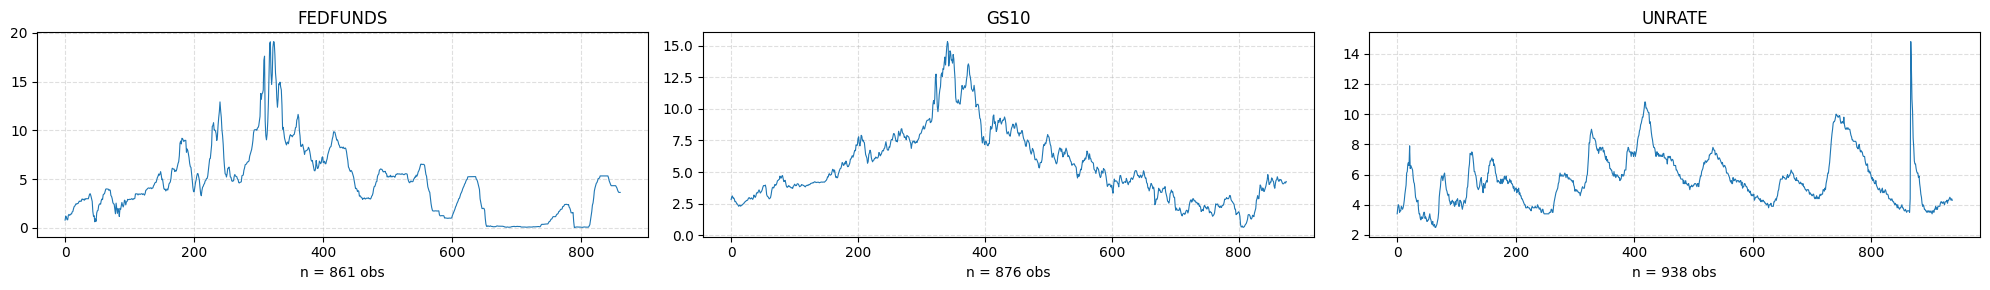

In [2]:
SeriesRegistry.clear()
SeriesRegistry.register_from_csv("GS10",     path="data/GS10.csv",     column="GS10")
SeriesRegistry.register_from_csv("UNRATE",   path="data/UNRATE.csv",   column="UNRATE")
SeriesRegistry.register_from_csv("FEDFUNDS", path="data/FEDFUNDS.csv", column="FEDFUNDS")

print("Loaded series:", SeriesRegistry.list_available())

fig, axes = plt.subplots(1, 3, figsize=(20, 3))
for ax, name in zip(axes, SeriesRegistry.list_available()):
    ts = SeriesRegistry.get(name)
    ax.plot(ts.values, linewidth=0.8)
    ax.set_title(name)
    ax.set_xlabel(f"n = {len(ts.values)} obs")
    ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 2. Configuration — Series & Forecaster Knobs

In [3]:
# ── Series & run settings ────────────────────────────────────────────────
rs_series = widgets.Dropdown(
    options=SeriesRegistry.list_available(),
    description='Series:',
    style={'description_width': 'initial'},
)

rs_horizon = widgets.IntSlider(
    value=1, min=1, max=24, step=1,
    description='Horizon (h):',
    style={'description_width': 'initial'},
)

rs_k_first = widgets.BoundedIntText(
    value=120, min=12, max=9000,
    description='Training window (k_first):',
    style={'description_width': 'initial'},
)

rs_rolling_window = widgets.IntSlider(
    value=20, min=5, max=200, step=5,
    description='Rolling MSE window:',
    style={'description_width': 'initial'},
)

# ── Naive benchmark ──────────────────────────────────────────────────────
rs_use_naive     = widgets.Checkbox(value=True, description='Naive benchmark (rule-based)')
rs_naive_rho_thr = widgets.FloatSlider(
    value=0.7, min=0.0, max=1.0, step=0.05,
    description='  \u03c1 threshold:',
    style={'description_width': 'initial'},
    readout_format='.2f',
)
rs_naive_window  = widgets.BoundedIntText(
    value=60, min=1, max=9000,
    description='  Mean window (mean mode):',
    style={'description_width': 'initial'},
)

# ── AR(1) standalone forecaster ──────────────────────────────────────────
rs_use_ar1 = widgets.Checkbox(value=True, description='AR(1)')

# ── Auto-ARIMA (BIC) ─────────────────────────────────────────────────────
rs_use_auto_arima = widgets.Checkbox(value=True, description='Auto-ARIMA (BIC)')
rs_arima_p_max    = widgets.IntSlider(
    value=4, min=0, max=12, step=1,
    description='  p_max:',
    style={'description_width': 'initial'},
)
rs_arima_q_max    = widgets.IntSlider(
    value=2, min=0, max=6, step=1,
    description='  q_max:',
    style={'description_width': 'initial'},
)
rs_arima_d_cap    = widgets.BoundedIntText(
    value=2, min=0, max=2,
    description='  d cap (ADF):',
    style={'description_width': 'initial'},
)

# ── Forecaster toggles & parameters ─────────────────────────────────────
rs_use_bayes_ar      = widgets.Checkbox(value=True, description='Bayes AR (ridge / MN)')
rs_bayes_ar_p        = widgets.IntSlider(value=3, min=1, max=15, description='  BayesAR p:')
rs_bayes_ar_lambda   = widgets.FloatLogSlider(
    value=1.0, base=10, min=-3, max=3, step=0.25,
    description='  BayesAR \u03bb:',
    style={'description_width': 'initial'},
)
rs_bayes_ar_mode     = widgets.Dropdown(
    options=[('Ridge (\u03bbI)', 'ridge'), ('Minnesota', 'minnesota')],
    value='ridge',
    description='  BayesAR mode:',
    style={'description_width': 'initial'},
)
rs_bayes_ar_mn_decay = widgets.FloatSlider(
    value=2.0, min=0.0, max=4.0, step=0.25,
    description='  MN lag exp:',
    style={'description_width': 'initial'},
)
rs_bayes_ar_mn_rw    = widgets.Checkbox(value=True, description='  MN RW mean on \u03c6\u2081')

rs_use_ssa     = widgets.Checkbox(value=True,  description='SSA')
rs_use_timesfm = widgets.Checkbox(value=True,  description='TimesFM 2.5')

# ── ML-BayesAR (marginal-likelihood optimal \u03bb) ────────────────────────
rs_use_ml_bayes_ar   = widgets.Checkbox(value=True, description='ML-BayesAR (ML-\u03bb)')
rs_ml_bayes_p        = widgets.IntSlider(
    value=24, min=1, max=60, step=1,
    description='  p (lags):',
    style={'description_width': 'initial'},
)
rs_ml_bayes_mode     = widgets.Dropdown(
    options=[('Minnesota', 'minnesota'), ('Ridge (\u03bbI)', 'ridge')],
    value='minnesota',
    description='  ML-BayesAR mode:',
    style={'description_width': 'initial'},
)
rs_ml_bayes_mn_decay = widgets.FloatSlider(
    value=1.0, min=0.0, max=4.0, step=0.25,
    description='  MN lag exp:',
    style={'description_width': 'initial'},
)
rs_ml_bayes_mn_rw    = widgets.Checkbox(value=True, description='  MN RW mean on \u03c6\u2081')

display(
    widgets.HTML('<h4>Series &amp; run settings</h4>'),
    rs_series, rs_horizon, rs_k_first, rs_rolling_window,
    widgets.HTML('<h4>Forecasters</h4>'),
    rs_use_naive, rs_naive_rho_thr, rs_naive_window,
    rs_use_ar1,
    rs_use_auto_arima, rs_arima_p_max, rs_arima_q_max, rs_arima_d_cap,
    rs_use_bayes_ar, rs_bayes_ar_p, rs_bayes_ar_lambda,
    rs_bayes_ar_mode, rs_bayes_ar_mn_decay, rs_bayes_ar_mn_rw,
    rs_use_ml_bayes_ar, rs_ml_bayes_p, rs_ml_bayes_mode,
    rs_ml_bayes_mn_decay, rs_ml_bayes_mn_rw,
    rs_use_ssa, rs_use_timesfm,
)

HTML(value='<h4>Series &amp; run settings</h4>')

Dropdown(description='Series:', options=('FEDFUNDS', 'GS10', 'UNRATE'), style=DescriptionStyle(description_wid…

IntSlider(value=1, description='Horizon (h):', max=24, min=1, style=SliderStyle(description_width='initial'))

BoundedIntText(value=120, description='Training window (k_first):', max=9000, min=12, style=DescriptionStyle(d…

IntSlider(value=20, description='Rolling MSE window:', max=200, min=5, step=5, style=SliderStyle(description_w…

...

Dropdown(description='  ML-BayesAR mode:', options=(('Minnesota', 'minnesota'), ('Ridge (λI)', 'ridge')), styl…

FloatSlider(value=1.0, description='  MN lag exp:', max=4.0, step=0.25, style=SliderStyle(description_width='i…

Checkbox(value=True, description='  MN RW mean on φ₁')

Checkbox(value=True, description='SSA')

Checkbox(value=True, description='TimesFM 2.5')

## 3. Run Benchmark

In [7]:
rs_output  = widgets.Output()
rs_button  = widgets.Button(description='Run Benchmark', button_style='success')
rs_results = None

def _on_rs_run(btn):
    global rs_results
    with rs_output:
        clear_output(wait=True)

        ts = SeriesRegistry.get(rs_series.value)
        k  = rs_k_first.value
        if k >= len(ts.values) - rs_horizon.value:
            print(f'ERROR: k_first ({k}) is too large for series length ({len(ts.values)}).')
            return

        forecasters = []
        if rs_use_naive.value:
            forecasters.append(NaiveBenchmarkForecaster(
                rho_threshold=float(rs_naive_rho_thr.value),
                mean_window=rs_naive_window.value,
            ))
        if rs_use_ar1.value:
            forecasters.append(ARIMAForecaster(order=(1, 0, 0)))
        if rs_use_auto_arima.value:
            forecasters.append(AutoARIMAForecaster(
                p_max=rs_arima_p_max.value,
                q_max=rs_arima_q_max.value,
                d_max=rs_arima_d_cap.value,
            ))
        if rs_use_bayes_ar.value:
            forecasters.append(BayesianARForecaster(
                p=rs_bayes_ar_p.value,
                prior_precision=float(rs_bayes_ar_lambda.value),
                prior_mode=str(rs_bayes_ar_mode.value),
                minnesota_lag_decay_exponent=float(rs_bayes_ar_mn_decay.value),
                minnesota_center_rw=rs_bayes_ar_mn_rw.value,
            ))
        if rs_use_ml_bayes_ar.value:
            forecasters.append(MLBayesARForecaster(
                p=rs_ml_bayes_p.value,
                prior_mode=str(rs_ml_bayes_mode.value),
                minnesota_lag_decay_exponent=float(rs_ml_bayes_mn_decay.value),
                minnesota_center_rw=rs_ml_bayes_mn_rw.value,
            ))
        if rs_use_ssa.value:
            forecasters.append(SSAForecaster())
        if rs_use_timesfm.value:
            forecasters.append(TimesFMForecaster(max_context=512))

        if not forecasters:
            print('Select at least one forecaster.')
            return

        runner = BenchmarkRunner(
            series=ts,
            forecasters=forecasters,
            k_first=k,
            horizon=rs_horizon.value,
            verbose=True,
        )

        print(f'Running benchmark on "{rs_series.value}" '
              f'(n={len(ts.values)}, k_first={k}, h={rs_horizon.value})...\n')
        rs_results = runner.run()

        print('\n\u2500\u2500 Summary metrics \u2500\u2500')
        display(rs_results.summary())
        print('\n\u2500\u2500 Diebold-Mariano (SE loss) \u2500\u2500')
        display(rs_results.diebold_mariano())

rs_button.on_click(_on_rs_run)
display(rs_button, rs_output)

Button(button_style='success', description='Run Benchmark', style=ButtonStyle())

Output()

## 4. Point Forecast Results — Charts & Scorecard

In [5]:
if rs_results is not None:
    _sc = rs_results.summary().copy()

    # ── RMSE/MEAN ratio ──────────────────────────────────────────────────
    _mean_row = _sc[_sc['Forecaster'] == 'Naive']
    if not _mean_row.empty:
        _mean_rmse = float(_mean_row['RMSE'].iloc[0])
        _sc['RMSE/Naive'] = _sc['RMSE'] / _mean_rmse if _mean_rmse > 0 else float('nan')
    else:
        _sc['RMSE/Naive'] = float('nan')

    _forecasters = _sc['Forecaster'].tolist()
    _x = np.arange(len(_forecasters))
    _width = 0.35

    fig, axes = plt.subplots(1, 3, figsize=(22, 5))

    # ── Bar chart: MAE & MSE ──────────────────────────────────────────────
    axes[0].bar(_x - _width / 2, _sc['MAE'], _width, label='MAE', color='steelblue')
    axes[0].bar(_x + _width / 2, _sc['MSE'], _width, label='MSE', color='darkorange')
    axes[0].set_xticks(_x)
    axes[0].set_xticklabels(_forecasters, rotation=15, ha='right')
    axes[0].set_title(f'MAE & MSE \u2014 {rs_results.series_name}')
    axes[0].set_ylabel('Error')
    axes[0].legend()
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    # ── Bar chart: RMSE / Mean-baseline RMSE ─────────────────────────────
    _ratio_vals = _sc['RMSE/Naive'].fillna(1.0).tolist()
    _colors = ['seagreen' if v <= 1.0 else 'firebrick' for v in _ratio_vals]
    axes[1].bar(_x, _ratio_vals, color=_colors)
    axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1.2, label='Naive baseline')
    axes[1].set_xticks(_x)
    axes[1].set_xticklabels(_forecasters, rotation=15, ha='right')
    axes[1].set_title('RMSE / Naive-baseline RMSE  \u2014  green < 1 = beats Naive')
    axes[1].set_ylabel('Ratio')
    axes[1].legend()
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)

    # ── Rolling MSE over time ─────────────────────────────────────────────
    rs_results.plot_mse_over_time(rolling_window=rs_rolling_window.value, ax=axes[2])

    plt.tight_layout()
    plt.show()

    # ── Cumulative error ──────────────────────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(14, 4))
    rs_results.plot_cumulative_error(ax=ax2)
    plt.tight_layout()
    plt.show()

    # ── Scorecard table ───────────────────────────────────────────────────
    print('\n\u2500\u2500 Scorecard (MSE, MAE, RMSE, RMSE/Naive ratio) \u2500\u2500')
    _num = [c for c in _sc.columns if c != 'Forecaster']
    try:
        display(
            _sc.style
            .format({c: '{:,.5f}' for c in _num}, na_rep='\u2014')
            .set_properties(subset=_num, **{'text-align': 'right'})
            .set_table_styles(
                [{'selector': 'th', 'props': [('text-align', 'left')]}], overwrite=False
            )
            .background_gradient(subset=['RMSE/Naive'], cmap='RdYlGn_r')
        )
    except Exception:
        display(_sc.round(5))
else:
    print('Run the benchmark first (cell above).')

Run the benchmark first (cell above).


## 5. Probabilistic Results — Coverage, CRPS & Calibration

Only forecasters that emit quantile predictions (ARIMA, BayesAR, TimesFM) appear here.

In [6]:
if rs_results is not None:
    # ── Coverage by nominal level ─────────────────────────────────────────
    cov = rs_results.coverage_table()
    cov = cov[cov['N_valid'] > 0].reset_index(drop=True)

    if cov.empty:
        print('No quantile forecasts available (enable ARIMA, BayesAR, or TimesFM).')
    else:
        print('\u2500\u2500 Coverage by nominal level (quantile forecasters only) \u2500\u2500')
        fmt = {'Nominal': '{:.0%}', 'Empirical_coverage': '{:.3f}', 'N_valid': '{:.0f}'}
        try:
            display(
                cov.style.format(fmt, na_rep='\u2014')
                .set_properties(**{'text-align': 'right'})
                .set_table_styles(
                    [{'selector': 'th', 'props': [('text-align', 'left')]}], overwrite=False
                )
            )
        except Exception:
            display(cov.round(4))

    # ── Probabilistic summary (CRPS, PI width, pinball) ───────────────────
    prob = rs_results.probabilistic_summary()
    if not prob.empty:
        print('\n\u2500\u2500 Probabilistic summary (CRPS, PI width @ 90%, pinball) \u2500\u2500')
        _pnum = [c for c in prob.columns if c != 'Forecaster']
        try:
            display(
                prob.style
                .format({c: '{:.5f}' for c in _pnum}, na_rep='\u2014')
                .background_gradient(subset=['CRPS'], cmap='RdYlGn_r')
                .set_properties(subset=_pnum, **{'text-align': 'right'})
                .set_table_styles(
                    [{'selector': 'th', 'props': [('text-align', 'left')]}], overwrite=False
                )
            )
        except Exception:
            display(prob.round(4))

        # ── Phase 2 scorecard @ 90% (KDE log score + sharpness) ──────────
        ph2 = rs_results.probabilistic_summary_phase2(nominal=0.9)
        ph2 = ph2[ph2['N_valid'] > 0].reset_index(drop=True)
        if not ph2.empty:
            keep = ['Forecaster', 'Empirical_coverage', 'Coverage_error',
                    'Mean_PI_width', 'mean_log_score_kde']
            keep = [c for c in keep if c in ph2.columns]
            ph2 = ph2[keep].rename(columns={
                'Empirical_coverage': 'Coverage (90%)',
                'Coverage_error':     'Coverage error',
                'Mean_PI_width':      'PI width',
                'mean_log_score_kde': 'Log score (KDE)',
            })
            print('\n\u2500\u2500 Phase 2 scorecard @ 90% \u2500\u2500')
            _ph2num = [c for c in ph2.columns if c != 'Forecaster']
            _ls_col = [c for c in ['Log score (KDE)'] if c in ph2.columns]
            try:
                s = ph2.style.format({c: '{:.4f}' for c in _ph2num}, na_rep='\u2014')
                if _ls_col:
                    s = s.background_gradient(subset=_ls_col, cmap='RdYlGn')
                display(
                    s.set_properties(subset=_ph2num, **{'text-align': 'right'})
                    .set_table_styles(
                        [{'selector': 'th', 'props': [('text-align', 'left')]}], overwrite=False
                    )
                )
            except Exception:
                display(ph2.round(4))

        # ── PIT histograms ────────────────────────────────────────────────
        _q_names = [
            n for n in rs_results.forecaster_names
            if rs_results.quantile_predictions and n in rs_results.quantile_predictions
        ]
        if _q_names:
            fig3, axes3 = plt.subplots(1, len(_q_names), figsize=(6 * len(_q_names), 4))
            if len(_q_names) == 1:
                axes3 = [axes3]
            for _ax, _name in zip(axes3, _q_names):
                rs_results.plot_pit_histogram(_name, ax=_ax)
            plt.suptitle('PIT histograms  \u2014  uniform = well calibrated', y=1.02)
            plt.tight_layout()
            plt.show()

            fig4, ax4 = plt.subplots(figsize=(6, 5))
            rs_results.plot_sharpness_vs_calibration(nominal=0.9, ax=ax4)
            plt.tight_layout()
            plt.show()
    else:
        print('No probabilistic forecasts available (enable ARIMA, BayesAR, or TimesFM).')
else:
    print('Run the benchmark first (cell above).')

Run the benchmark first (cell above).
